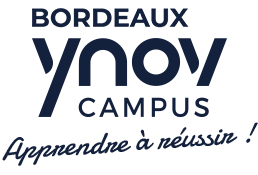

# TP1 — NumPy avancé, exploration + PCA, régression logistique from scratch

> **Cours Deep Learning · Ynov Bordeaux · EIA Mastère 2** — TP1 (J1)
> 3h · Livrable : notebook complété avec courbes (coût, accuracy, α), projection PCA 2D et variance cumulée

**Comment travailler :** exécutez les cellules dans l'ordre. Les cellules marquées `# TODO` sont à compléter. Utilisez `assert` sur les formes dès que vous manipulez des tenseurs. Une cellule à compléter échoue tant que son `TODO` n'est pas fait : c'est normal. Le TP se termine en séance et le corrigé est distribué en fin de TP ; il n'y a rien à rendre.

## Partie 0 — Cadrer avant de coder (5 min)

Avant la première ligne de NumPy, les réflexes du cours du matin. Répondez en commentaire dans la cellule : le type d'apprentissage, la métrique, la baseline. Le jeu de données du TP est Fashion-MNIST : 70 000 images 28 × 28 en niveaux de gris, dix catégories de vêtements.

In [37]:
# TODO : répondre en commentaire
# 1. Type d'apprentissage (supervisé ou non ? régression ou classification ?) pour la partie C ; et pour la PCA de la partie B ?
#    - Partie C : apprentissage SUPERVISÉ de CLASSIFICATION (binaire : T-shirt (0) vs Pantalon (1)).
#      On dispose des labels y et on cherche à prédire une catégorie discrète, pas une valeur continue.
#    - Partie B (PCA) : apprentissage NON SUPERVISÉ. La PCA ne regarde que X (pas y) pour trouver les
#      directions de variance maximale ; y n'est utilisé qu'après coup, pour colorer le scatter.

# 2. Métrique d'apprentissage (ce que le modèle minimise) et métrique de décision (ce qu'on regarde pour comparer)
#    - Métrique d'apprentissage : la perte logistique / binary cross-entropy J (moyenne sur les m exemples),
#      c'est elle que la descente de gradient minimise directement.
#    - Métrique de décision : l'accuracy (taux de bonnes prédictions après seuillage à 0.5 sur dev/test),
#      c'est elle qui sert à comparer les modèles entre eux (elle n'est pas différentiable, donc pas utilisée pour l'optimisation).

# 3. Baseline : quelle règle la plus simple le modèle doit-il battre, et quelle accuracy donne-t-elle ?
#    - La règle la plus simple est de prédire systématiquement la classe majoritaire de Yb_dev.
#    - Les classes T-shirt/Pantalon étant quasi équilibrées (~50/50) dans Fashion-MNIST,
#      cette baseline "classe majoritaire" donne une accuracy proche de 0.50.
#    - La règle de bon sens (seuil sur la luminosité totale de l'image) doit faire mieux que cette baseline
#      pour être jugée pertinente, et la régression logistique doit elle-même battre les deux.

# 4. Forme de X dans la notation du cours (un exemple par colonne) pour m images 28 × 28
#    - X a la forme (n_x, m) avec n_x = 28*28 = 784 (pixels aplatis en une colonne) et m le nombre d'images.
#    - Chaque colonne de X est donc une image, chaque ligne est un pixel ; X.shape == (784, m).

## Partie A — NumPy avancé (45 min)

Objectif : ne plus jamais écrire de boucle `for` sur des nombres, et vérifier systématiquement les formes.

In [38]:
import numpy as np, time, matplotlib.pyplot as plt
rng = np.random.default_rng(0)

### A1. Reshape d'un batch d'images
Un batch de 8 images 28×28 en niveaux de gris doit devenir une matrice `X` de forme `(784, 8)` (convention du cours : un exemple par colonne).

In [39]:
imgs = rng.integers(0, 256, size=(8, 28, 28)).astype("float32")     # (m, H, W)
X = imgs.reshape(imgs.shape[0], -1).T / 255.0   # (m, 784) puis transposée -> (784, m), normalisation dans [0, 1]
assert X.shape == (784, 8)
assert np.allclose(X[:, 3], imgs[3].ravel() / 255.0)

### A2. Broadcasting
Centrer chaque **feature** (ligne de X) et normaliser des colonnes pour qu'elles somment à 1, sans boucle.

In [40]:
mu = X.mean(axis=1, keepdims=True)      # moyenne par feature (sur les exemples, axis=1), (784, 1)
Xc = X - mu                              # broadcasting (784, 8) - (784, 1)
assert Xc.shape == X.shape and np.allclose(Xc.mean(axis=1), 0, atol=1e-6)

A = rng.random((3, 4))
A_pct = A / A.sum(axis=0, keepdims=True)   # chaque colonne somme à 1
assert np.allclose(A_pct.sum(axis=0), 1)

### A3. `einsum` et produits
Réécrire un produit matriciel, un produit scalaire par colonne et une somme de produits externes avec `np.einsum`.

In [41]:
W = rng.normal(size=(4, 784)); B = rng.normal(size=(784, 8))
Z2 = np.einsum("ij,jk->ik", W, B)      # produit matriciel W·B avec einsum
assert np.allclose(W @ B, Z2)
dots = np.einsum("ij,ij->j", B, B)     # produit scalaire de chaque colonne de B avec elle-même -> forme (8,)
assert np.allclose(dots, (B * B).sum(axis=0))

### A4. Benchmark : boucle vs vectorisé

In [42]:
a, b = rng.random(1_000_000), rng.random(1_000_000)
t0 = time.perf_counter(); s = 0.0
for i in range(len(a)): s += a[i] * b[i]
t_loop = time.perf_counter() - t0
t0 = time.perf_counter(); s2 = np.dot(a, b); t_vec = time.perf_counter() - t0
print(f"boucle : {t_loop*1000:.1f} ms | vectorisé : {t_vec*1000:.3f} ms | facteur x{t_loop/t_vec:.0f}")
assert abs(s - s2) < 1e-6 * abs(s2) + 1e-6

boucle : 153.9 ms | vectorisé : 1.285 ms | facteur x120


### A5. Le piège du vecteur « rang 1 »
Montrez que `a.T` ne fait rien sur un `(5,)` et corrigez avec `reshape`.

In [43]:
a = rng.normal(size=5)
print(a.shape, a.T.shape)      # que remarquez-vous ? -> identiques : un vecteur "rang 1" (5,) n'a pas de notion de ligne/colonne, .T ne fait rien
a = a.reshape(5, 1)            # en faire un vecteur colonne (5, 1)
assert a.shape == (5, 1)

(5,) (5,)


## Partie B — Exploration et PCA sur Fashion-MNIST (60 min)

In [44]:
# Fashion-MNIST : 70 000 images 28 x 28 en niveaux de gris, 10 classes. Via torchvision si disponible, sinon via scikit-learn (OpenML).
CLASSES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
try:
    from torchvision import datasets
    train_ds = datasets.FashionMNIST("data", train=True, download=True)
    test_ds  = datasets.FashionMNIST("data", train=False, download=True)
    X_all = train_ds.data.numpy().reshape(len(train_ds), -1).astype("float32") / 255.0   # (60000, 784), pixels ramenés dans [0, 1]
    y_all = train_ds.targets.numpy()
    X_test = test_ds.data.numpy().reshape(len(test_ds), -1).astype("float32") / 255.0
    y_test = test_ds.targets.numpy()
except ImportError:
    from sklearn.datasets import fetch_openml
    fm = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="auto")        # 70 000 x 784, téléchargement de 30 Mo
    Xf = fm.data.astype("float32") / 255.0; yf = fm.target.astype(int)
    X_all, y_all, X_test, y_test = Xf[:60000], yf[:60000], Xf[60000:], yf[60000:]
# split train / dev (le test reste intouché jusqu'à la fin)
rng = np.random.default_rng(0); idx = rng.permutation(len(X_all))
X_train, y_train = X_all[idx[:50000]], y_all[idx[:50000]]
X_dev,   y_dev   = X_all[idx[50000:]], y_all[idx[50000:]]
print(X_train.shape, X_dev.shape, X_test.shape, CLASSES)

(50000, 784) (10000, 784) (10000, 784) ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### B1. Regarder les données
Distribution des classes, 20 images au hasard, image moyenne par classe.

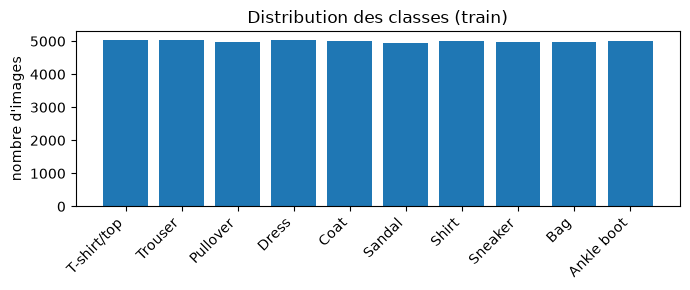

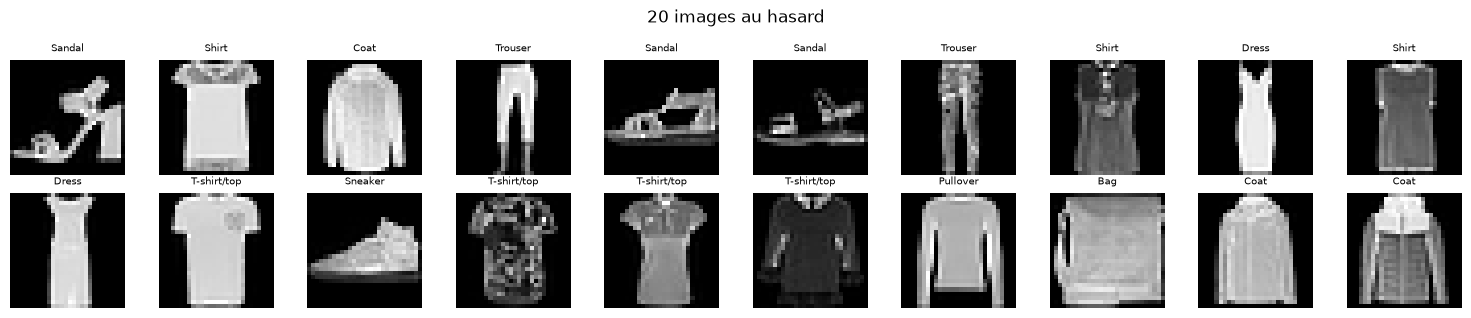

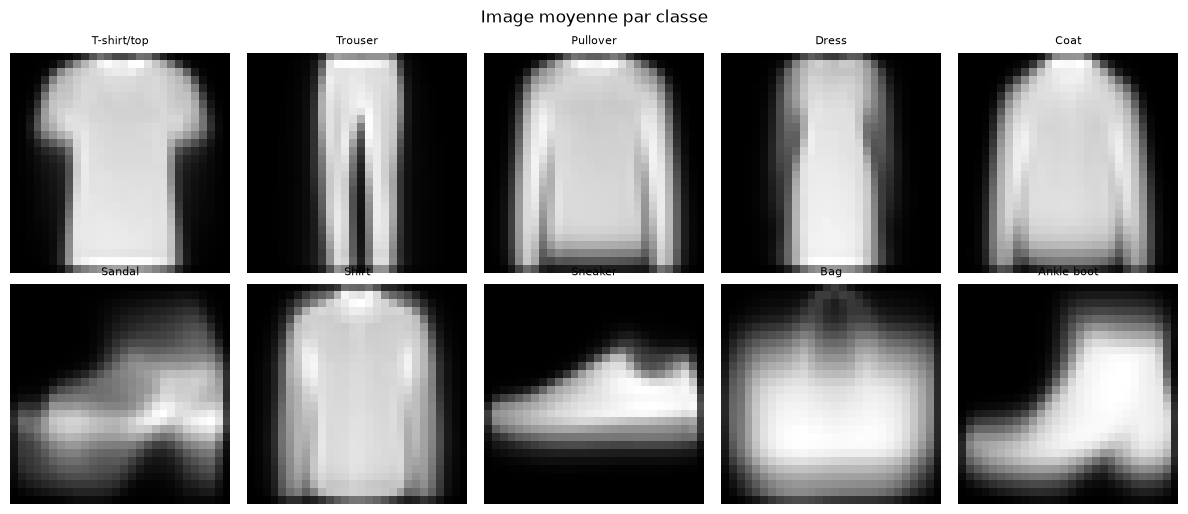

In [45]:
# Distribution des classes
counts = np.bincount(y_train)
plt.figure(figsize=(7, 3))
plt.bar(range(10), counts)
plt.xticks(range(10), CLASSES, rotation=45, ha="right")
plt.ylabel("nombre d'images")
plt.title("Distribution des classes (train)")
plt.tight_layout(); plt.show()

# 20 images au hasard
idx = rng.integers(0, len(X_train), size=20)
fig, axes = plt.subplots(2, 10, figsize=(15, 3.2))
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray")
    ax.set_title(CLASSES[y_train[i]], fontsize=7)
    ax.axis("off")
plt.suptitle("20 images au hasard"); plt.tight_layout(); plt.show()

# Image moyenne par classe
fig, axes = plt.subplots(2, 5, figsize=(12, 5.2))
for c, ax in zip(range(10), axes.ravel()):
    mean_img = X_train[y_train == c].mean(axis=0)
    ax.imshow(mean_img.reshape(28, 28), cmap="gray")
    ax.set_title(CLASSES[c], fontsize=8)
    ax.axis("off")
plt.suptitle("Image moyenne par classe"); plt.tight_layout(); plt.show()

### B2. PCA « à la main » avec la SVD
Standardiser, calculer les composantes, projeter en 2D, tracer la variance cumulée. Puis comparer à scikit-learn.

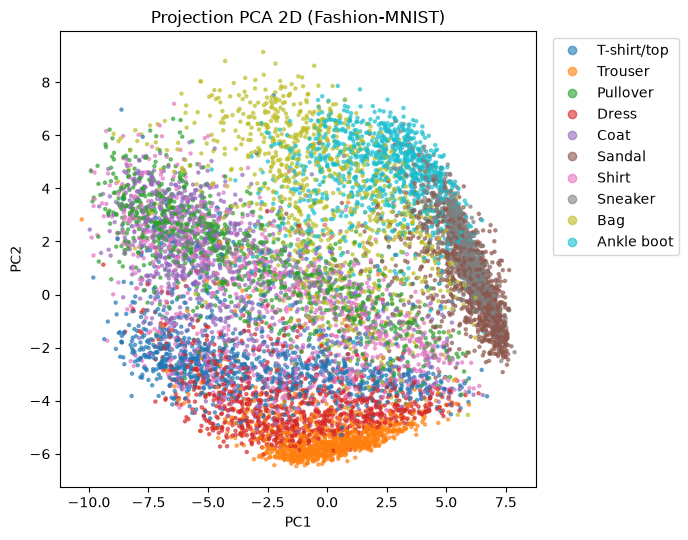

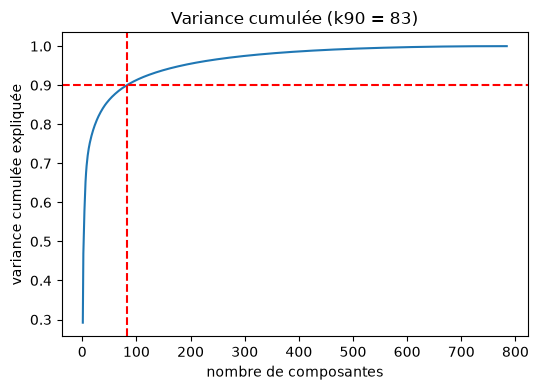

k90 = 83
projections identiques au signe près : True


In [46]:
Xs = X_train[:10000]; ys = y_train[:10000]
mu = Xs.mean(axis=0); Xc = Xs - mu   # on centre (standardiser par l'écart-type diviserait par ~0 sur les pixels de bord)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
var_exp = (S ** 2) / np.sum(S ** 2)                 # variance expliquée par composante
cum_var = np.cumsum(var_exp)
k90 = int(np.argmax(cum_var >= 0.90) + 1)           # nombre de composantes pour atteindre 90 %
Z = Xc @ Vt[:2].T                                    # projection 2D = Xc @ (2 premières lignes de Vt).T

# scatter coloré par classe
plt.figure(figsize=(7, 5.5))
sc = plt.scatter(Z[:, 0], Z[:, 1], c=ys, cmap="tab10", s=5, alpha=0.6)
plt.legend(handles=sc.legend_elements(num=10)[0], labels=CLASSES, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Projection PCA 2D (Fashion-MNIST)")
plt.tight_layout(); plt.show()

# courbe de variance cumulée
plt.figure(figsize=(5.5, 4))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var)
plt.axhline(0.90, color="r", linestyle="--")
plt.axvline(k90, color="r", linestyle="--")
plt.xlabel("nombre de composantes"); plt.ylabel("variance cumulée expliquée")
plt.title(f"Variance cumulée (k90 = {k90})")
plt.tight_layout(); plt.show()
print("k90 =", k90)

# comparaison à sklearn.decomposition.PCA(n_components=2) (au signe près)
from sklearn.decomposition import PCA
Z_sk = PCA(n_components=2).fit_transform(Xs)
print("projections identiques au signe près :", np.allclose(np.abs(Z), np.abs(Z_sk), atol=1e-3))

### B3. Reconstruction
Reconstruire une image avec k = 2, 12, 50, 200 composantes et observer.

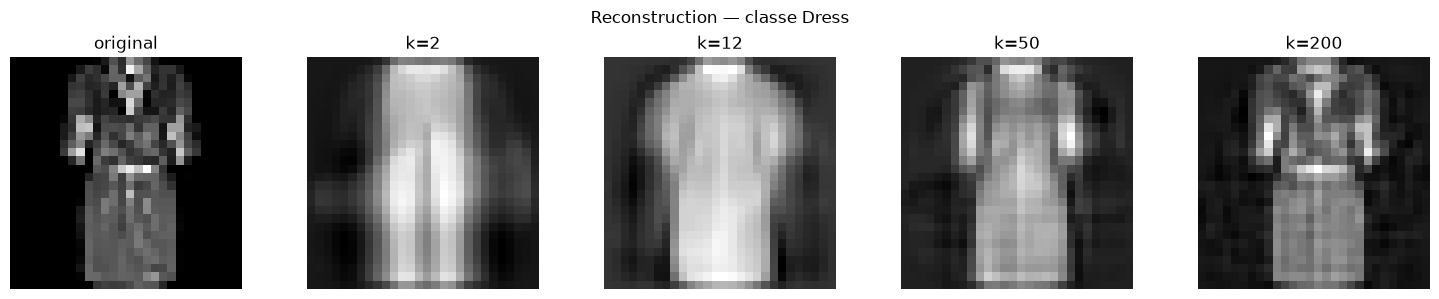

In [47]:
i = 7
ks = [2, 12, 50, 200]
fig, axes = plt.subplots(1, len(ks) + 1, figsize=(3 * (len(ks) + 1), 3))
axes[0].imshow(Xs[i].reshape(28, 28), cmap="gray"); axes[0].set_title("original"); axes[0].axis("off")
for ax, k in zip(axes[1:], ks):
    Zk = Xc[i] @ Vt[:k].T
    rec = Zk @ Vt[:k] + mu
    ax.imshow(rec.reshape(28, 28), cmap="gray")
    ax.set_title(f"k={k}"); ax.axis("off")
plt.suptitle(f"Reconstruction — classe {CLASSES[ys[i]]}")
plt.tight_layout(); plt.show()

## Partie C — Régression logistique from scratch (75 min)

Classifieur binaire **T-shirt (0) vs Pantalon (1)**. Convention du cours : `X` de forme `(n_x, m)`, `Y` de forme `(1, m)`.

In [48]:
def binary_subset(X, y, a=0, b=1):
    m = (y == a) | (y == b)
    return X[m].T.astype("float64"), (y[m] == b).astype("float64").reshape(1, -1)
Xb_train, Yb_train = binary_subset(X_train, y_train)
Xb_dev,   Yb_dev   = binary_subset(X_dev, y_dev)
print(Xb_train.shape, Yb_train.shape, Xb_dev.shape, "proportion de 1 :", Yb_train.mean())

(784, 10073) (1, 10073) (784, 1927) proportion de 1 : 0.4990568847413879


### C0. La baseline à battre
Avant tout modèle : la règle la plus simple. Classe majoritaire, puis une règle de bon sens : un pantalon a moins de pixels allumés qu'un T-shirt.

In [49]:
acc_majoritaire = max(Yb_dev.mean(), 1 - Yb_dev.mean())   # accuracy si l'on prédit toujours la classe la plus fréquente de Yb_dev
luminosite = Xb_dev.sum(axis=0)                            # somme des pixels de chaque image du dev, forme (m,)
seuil = np.median(Xb_train.sum(axis=0))                    # médiane de la même quantité calculée sur le TRAIN
acc_regle = ((luminosite < seuil).astype("float64") == Yb_dev[0]).mean()  # image plus sombre que le seuil -> pantalon (1)
print(acc_majoritaire, acc_regle)

0.5049299429164504 0.7176959003632589


### C1. Les briques : sigmoïde, propagation, coût, gradients

In [50]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def propagate(w, b, X, Y):
    m = X.shape[1]
    A = sigmoid(w.T @ X + b)                                        # (1, m)
    J = -np.mean(Y * np.log(A + 1e-8) + (1 - Y) * np.log(1 - A + 1e-8))  # perte logistique moyenne
    dZ = A - Y
    dw = (X @ dZ.T) / m    # (n_x, 1)
    db = np.mean(dZ)
    assert dw.shape == w.shape
    return J, dw, db

### C2. Descente de gradient et prédiction

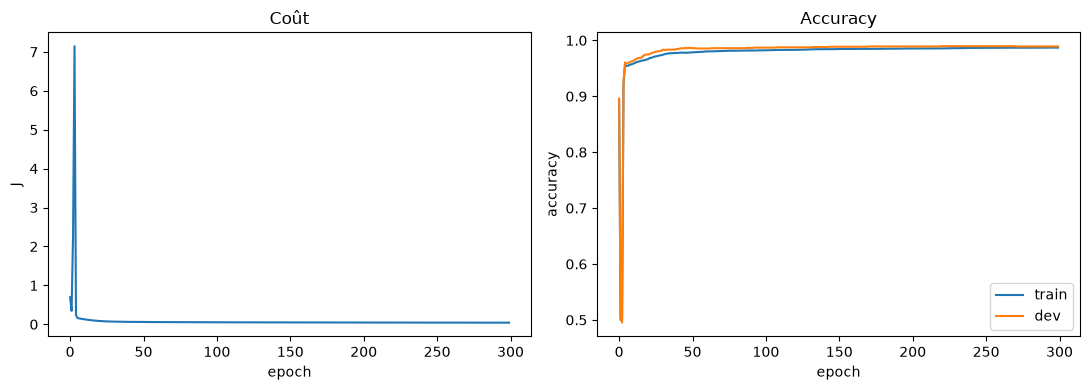

accuracy train : 0.9869949369601906 | accuracy dev : 0.9891022314478464


In [51]:
def train_logreg(X, Y, alpha=0.5, epochs=300, X_dev=None, Y_dev=None):
    n_x = X.shape[0]; w = np.zeros((n_x, 1)); b = 0.0
    hist = {"J": [], "acc_train": [], "acc_dev": []}
    for e in range(epochs):
        J, dw, db = propagate(w, b, X, Y)
        w = w - alpha * dw
        b = b - alpha * db
        hist["J"].append(J)
        hist["acc_train"].append(accuracy(w, b, X, Y))
        if X_dev is not None:
            hist["acc_dev"].append(accuracy(w, b, X_dev, Y_dev))
    return w, b, hist

def predict(w, b, X): return (sigmoid(w.T @ X + b) >= 0.5).astype("float64")
def accuracy(w, b, X, Y): return (predict(w, b, X) == Y).mean()

w, b, hist = train_logreg(Xb_train, Yb_train, alpha=0.5, epochs=300, X_dev=Xb_dev, Y_dev=Yb_dev)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist["J"]); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("J"); axes[0].set_title("Coût")
axes[1].plot(hist["acc_train"], label="train"); axes[1].plot(hist["acc_dev"], label="dev")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()
print("accuracy train :", accuracy(w, b, Xb_train, Yb_train), "| accuracy dev :", accuracy(w, b, Xb_dev, Yb_dev))

### C3. Effet du taux d'apprentissage
Comparer α ∈ {0,01 ; 0,1 ; 0,5 ; 3}. Lequel diverge ? Lequel est trop lent ?

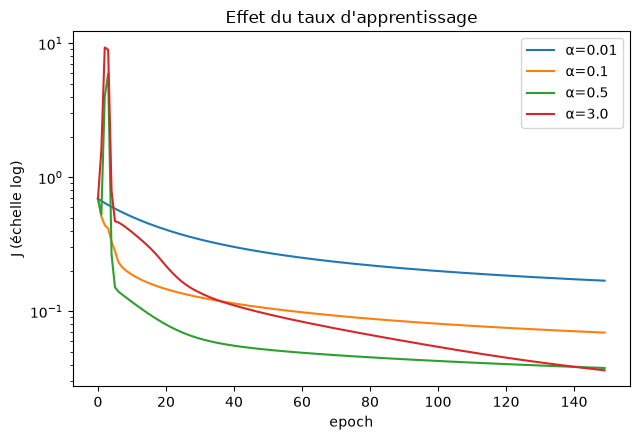

In [52]:
alphas = [0.01, 0.1, 0.5, 3.0]
X_sub, Y_sub = Xb_train[:, :2000], Yb_train[:, :2000]
plt.figure(figsize=(6.5, 4.5))
for a in alphas:
    _, _, h = train_logreg(X_sub, Y_sub, alpha=a, epochs=150)
    plt.plot(h["J"], label=f"α={a}")
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("J (échelle log)")
plt.title("Effet du taux d'apprentissage"); plt.legend(); plt.tight_layout(); plt.show()
# alpha=3.0 diverge (pas trop grand), alpha=0.01 est trop lent à converger, 0.1/0.5 sont de bons compromis

### C4. Interpréter les poids
Afficher `w` sous forme d'image 28×28 : où le modèle « regarde »-t-il pour distinguer un pantalon d'un T-shirt ?

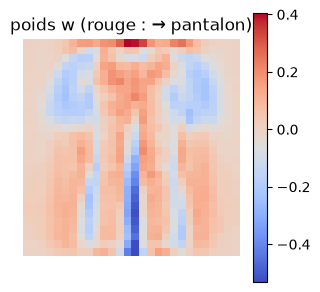

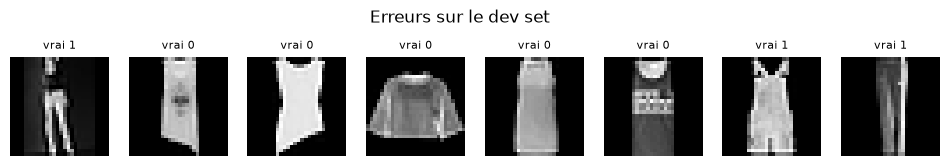

In [53]:
plt.figure(figsize=(3.5, 3.5)); plt.imshow(w.reshape(28, 28), cmap="coolwarm"); plt.colorbar(); plt.title("poids w (rouge : → pantalon)"); plt.axis("off"); plt.show()
errors = np.where(predict(w, b, Xb_dev) != Yb_dev)[1][:8]
fig, axes = plt.subplots(1, len(errors), figsize=(12, 2))
for ax, i in zip(axes, errors): ax.imshow(Xb_dev[:, i].reshape(28, 28), cmap="gray"); ax.set_title(f"vrai {int(Yb_dev[0, i])}", fontsize=8); ax.axis("off")
plt.suptitle("Erreurs sur le dev set"); plt.show()

## Pour aller plus loin
- Backpropagation à la main, comme sur la slide de l'appartement : x = 50, y = 150, w = 2, b = 10, J = (ŷ − y)². Écrire en NumPy la passe avant (ŷ, J), la passe arrière (dJ/dŷ, dJ/dw, dJ/db) et dix mises à jour avec α = 0,0001 ; vérifier que J passe de 1 600 à 400 puis à 100, et observer ce qui se passe avec α = 0,01.
- Remplacer la boucle sur les epochs par des mini-batchs de 64 : que devient la courbe de coût ?
- Étendre à 10 classes avec un softmax (`Z` de forme `(10, m)`, `dZ = A − Y_onehot`) — c'est le TP2.
- Comparer la PCA à 50 composantes + régression logistique vs 784 pixels : gain de temps ? perte de précision ?